<h1 style = "color:#09eeee;font-size:75px;font-style:italic;font-family:sherif;font-weight:bold;text-align:center"> Weather Prediction </h1>

<h1 style = "color:green;font-size:25px;font-style:italic;font-family:sherif;font-weight:bold"> Step 1 : Import Required Library & Dataset , Apply Data Preprocessing Steps , Exploratory Data Analysis  </h1>

    Temperature (°C)  Humidity (%)  Wind Speed (km/h)  Precipitation (%)    Cloud Cover  Atmospheric Pressure (hpa)  UV Index  Season  Visibility (km)  Location Weather Type
0               14.0            73                9.5               82.0  partly cloudy                     1010.82         2  Winter              3.5    inland        Rainy
1               39.0            96                8.5               71.0  partly cloudy                     1011.43         7  Spring             10.0    inland       Cloudy
2               30.0            64                7.0               16.0          clear                     1018.72         5  Spring              5.5  mountain        Sunny
3               38.0            83                1.5               82.0          clear                     1026.25         7  Spring              1.0   coastal        Sunny
4               27.0            74               17.0               66.0       overcast                      990.67         1  Win

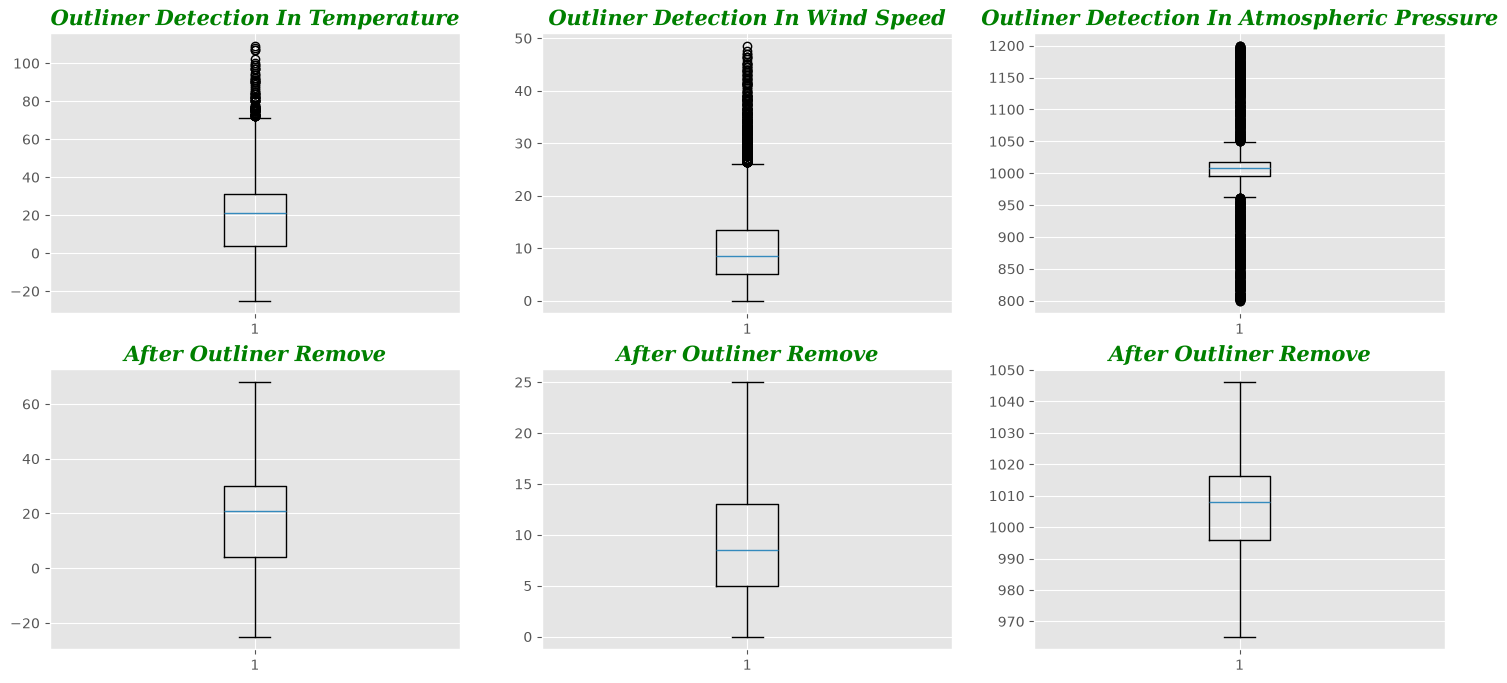

(8205, 11)


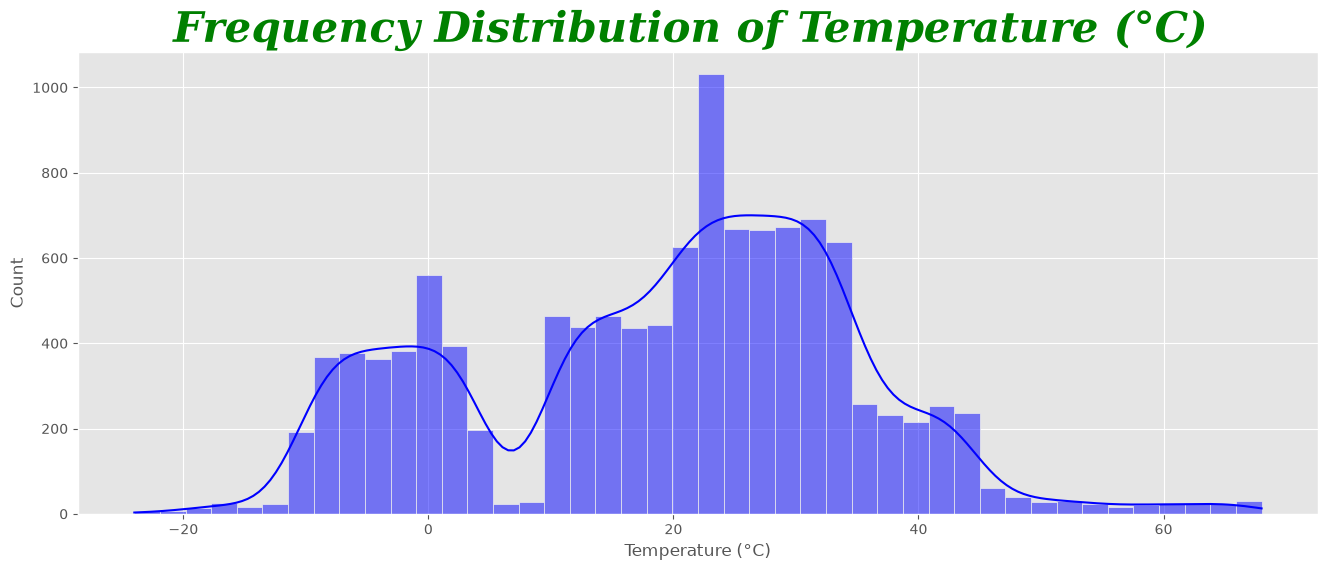

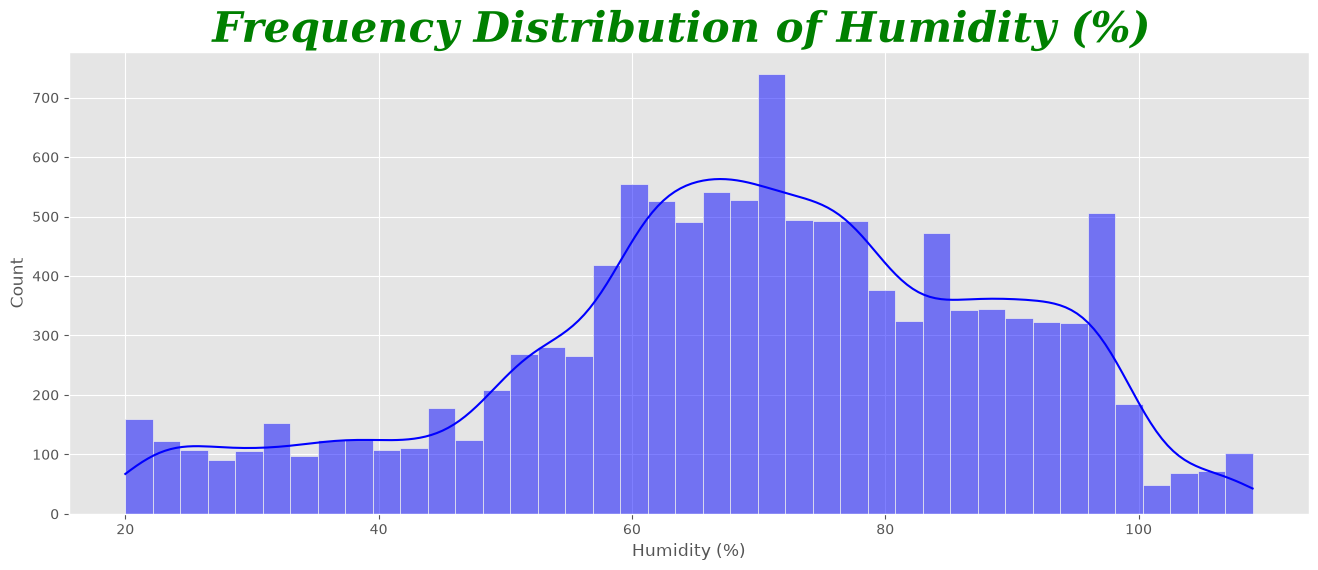

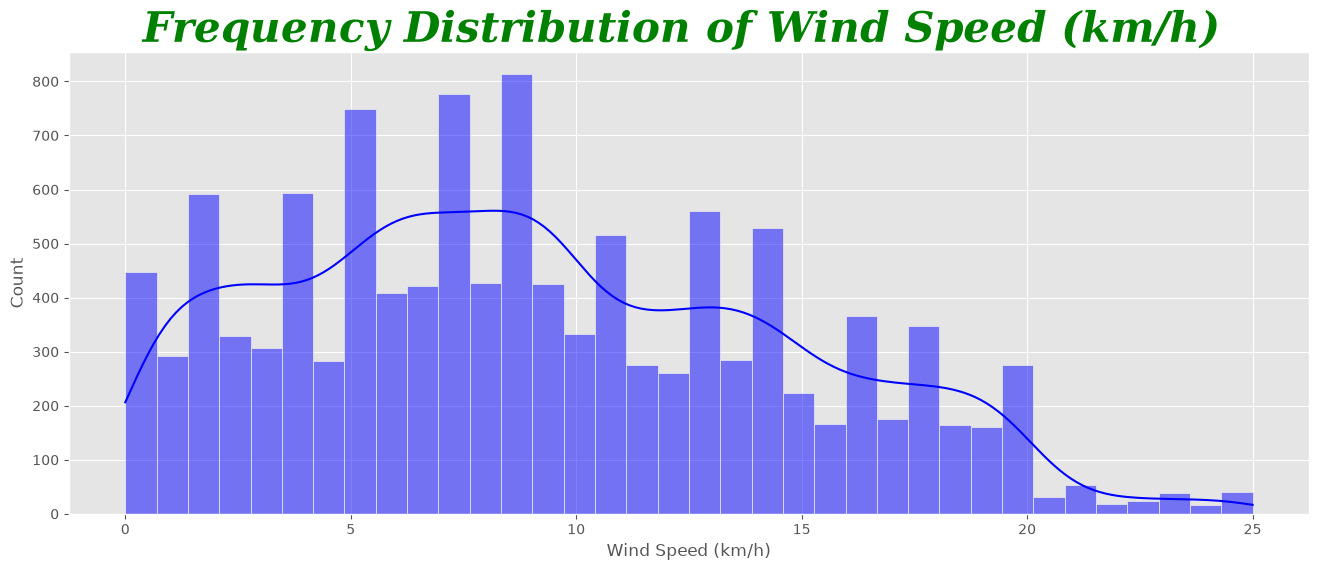

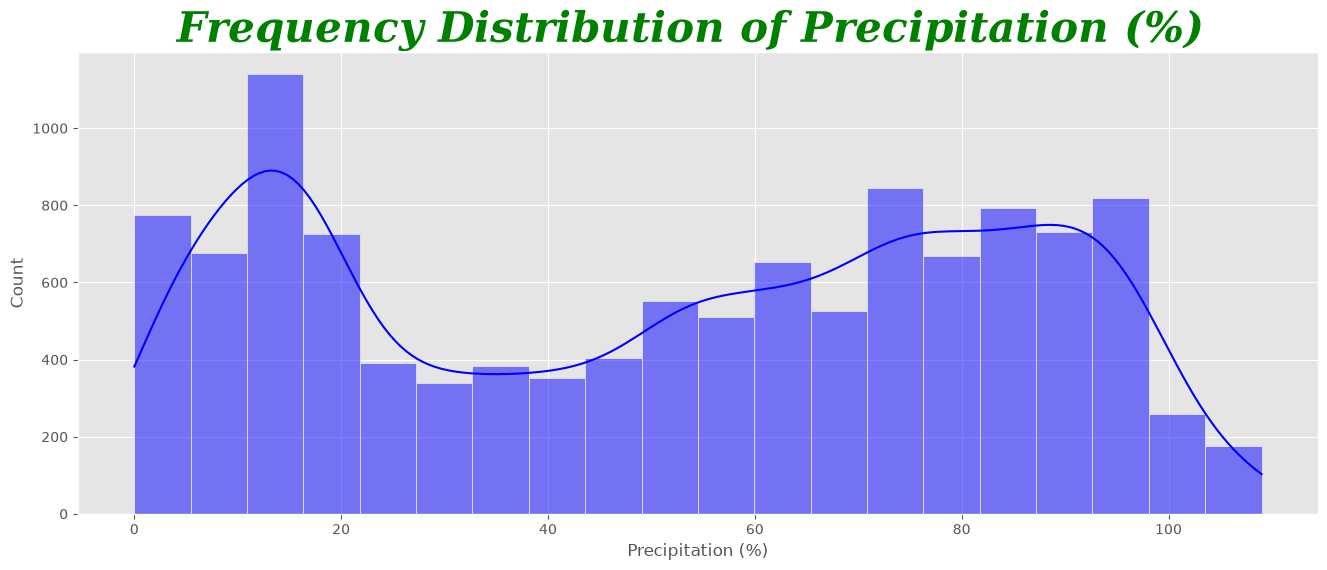

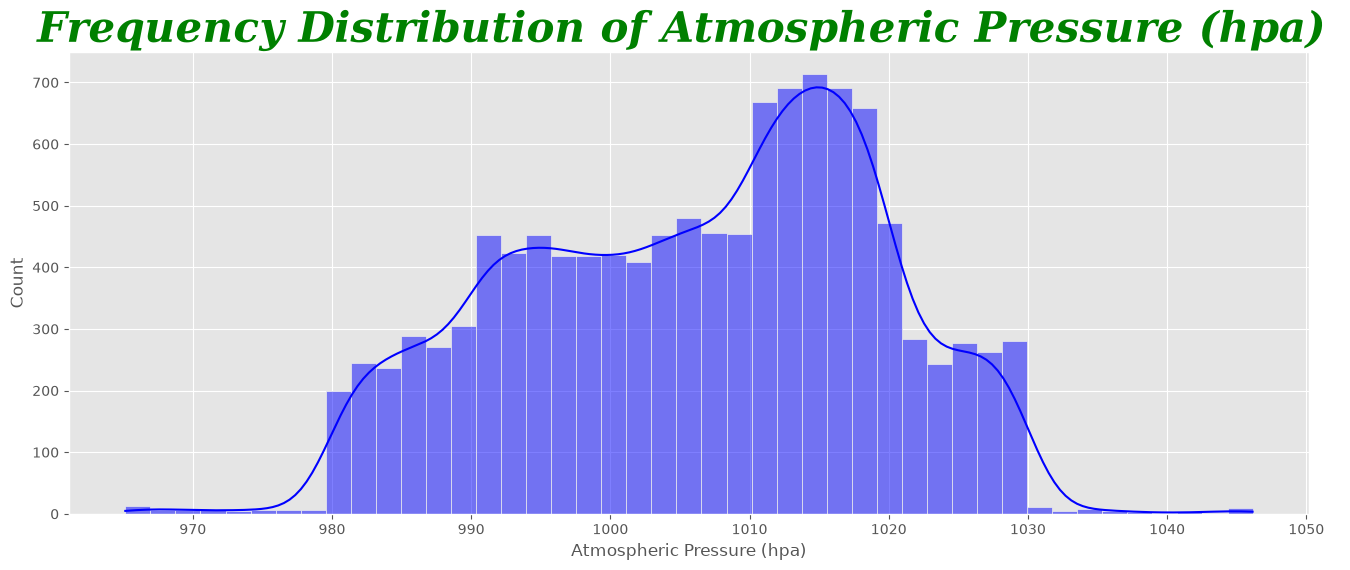

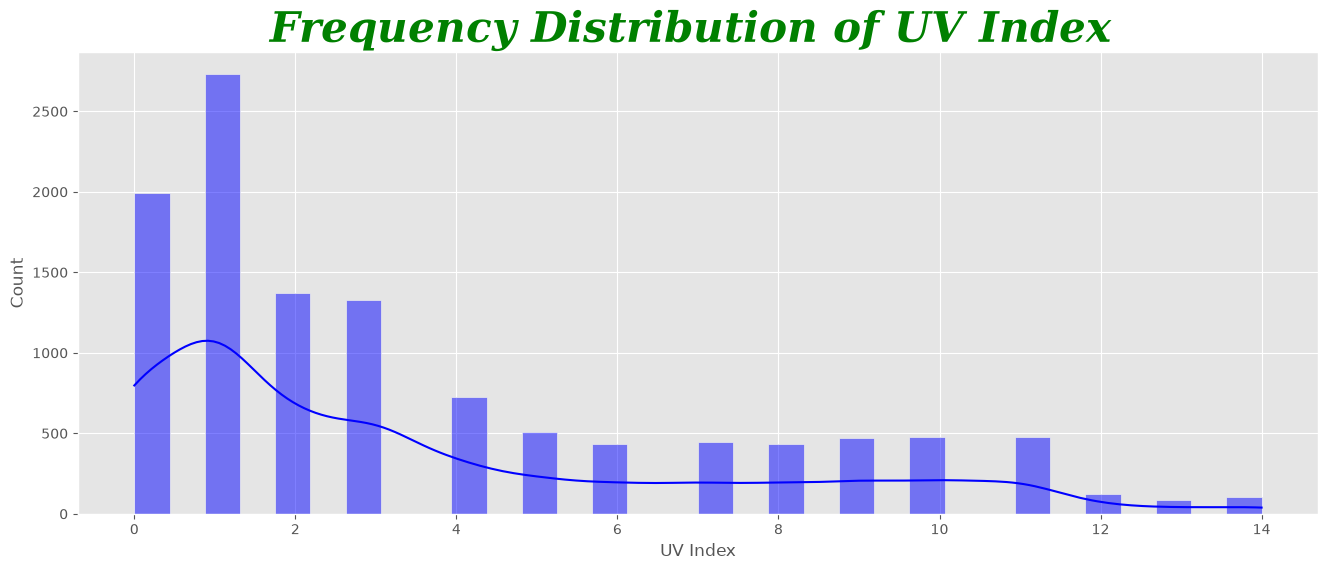

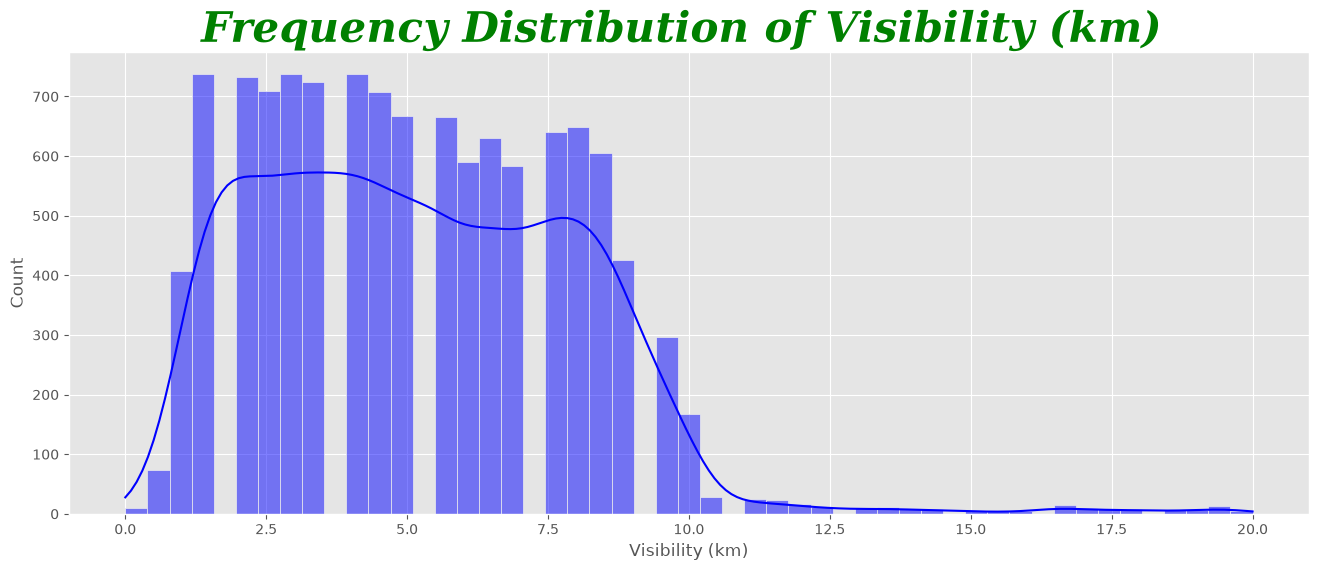

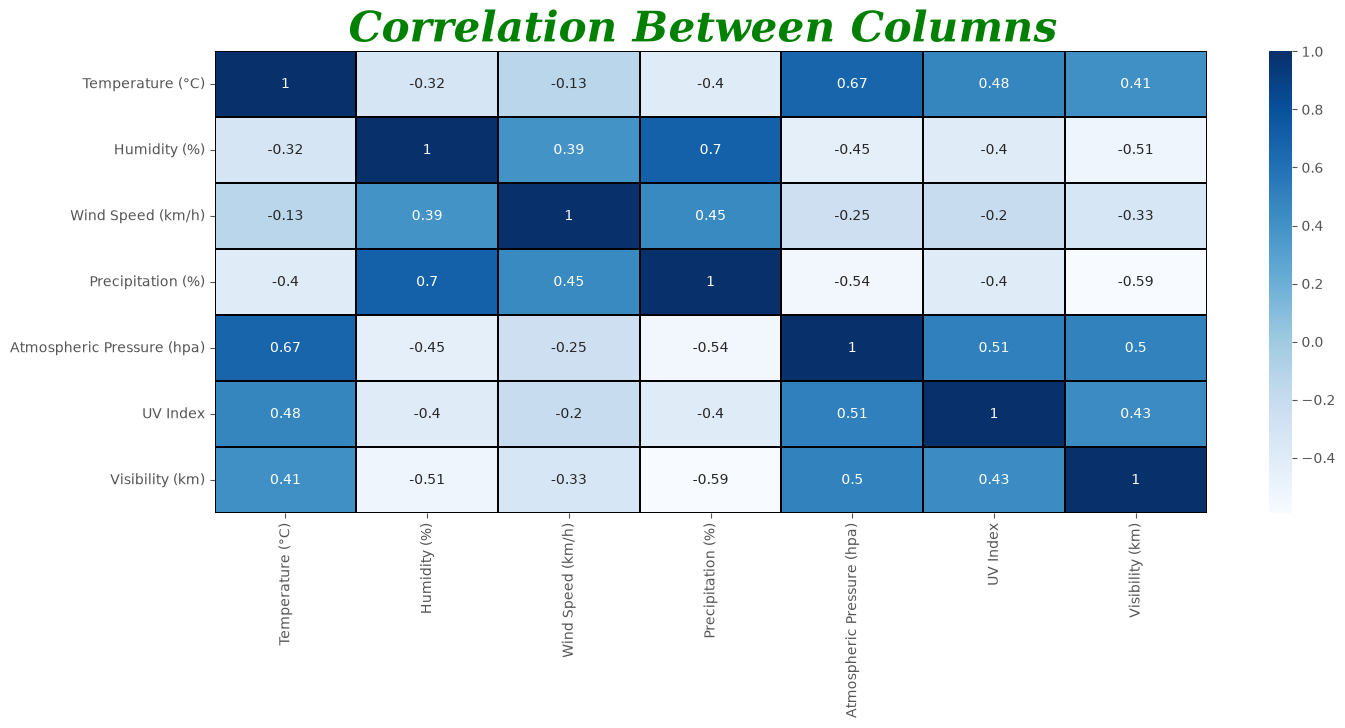

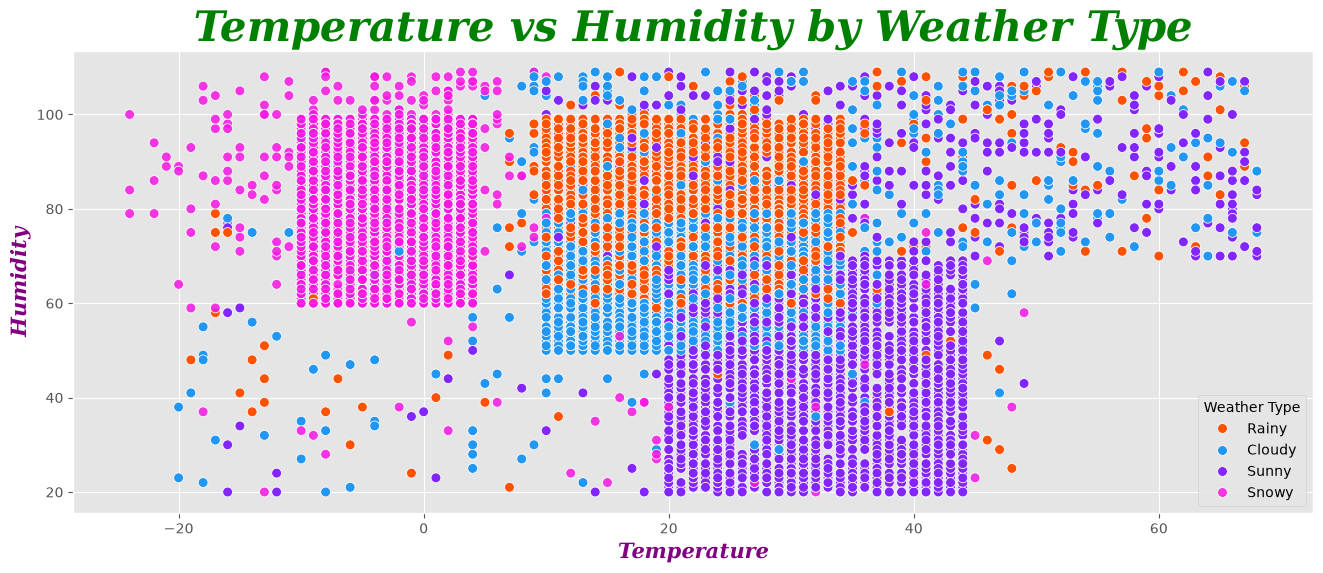

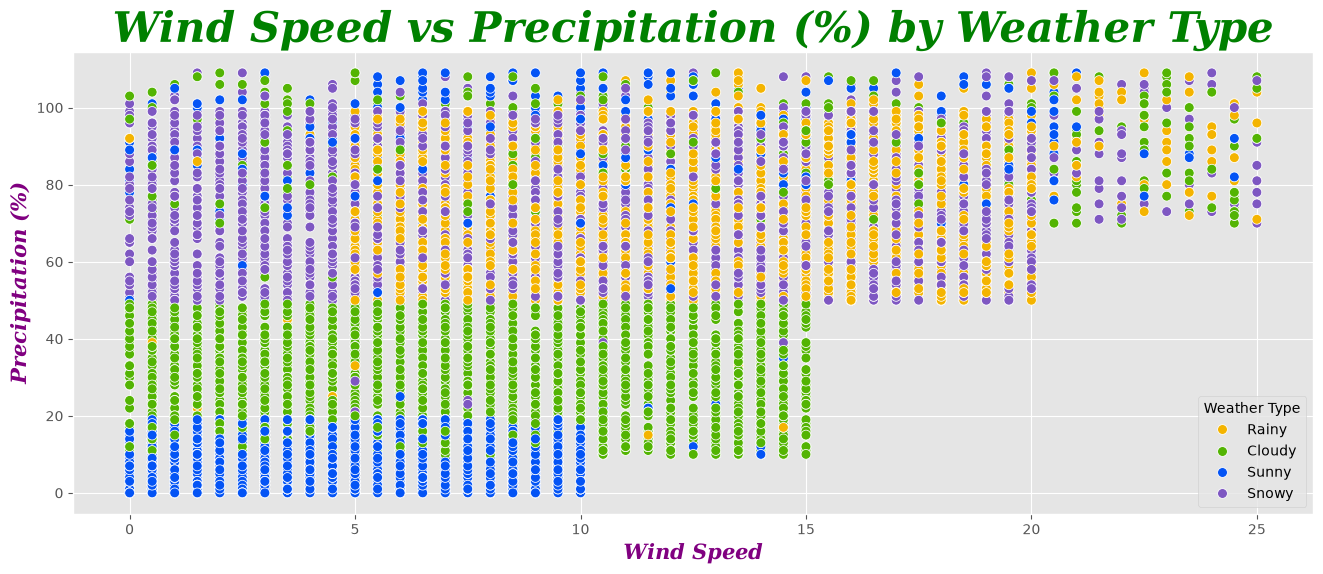

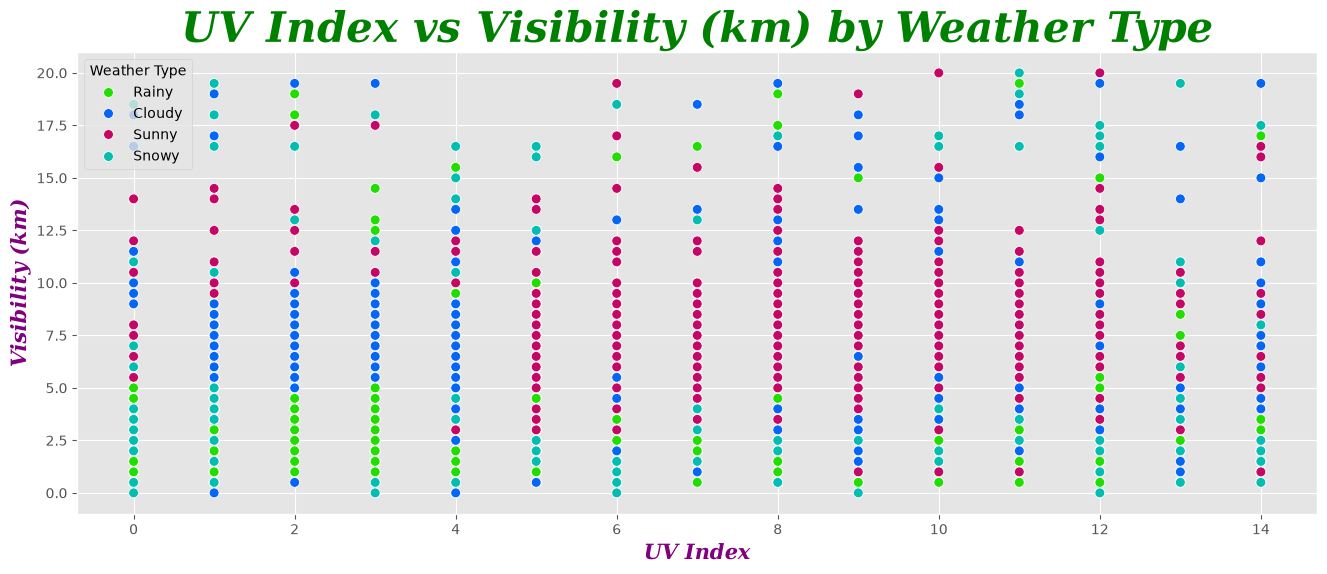

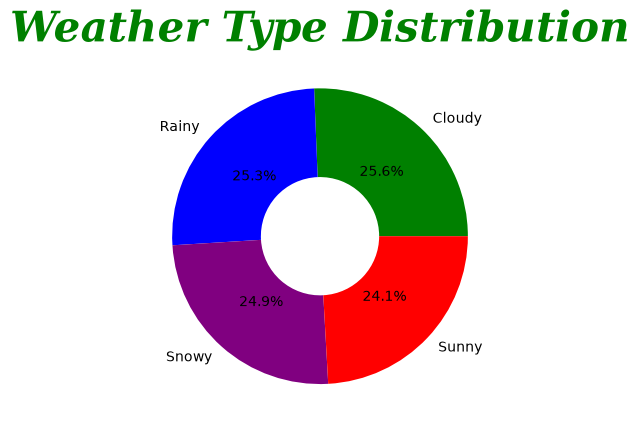

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)
pd.set_option('display.width',None)
pd.set_option('display.expand_frame_repr',False)

JP=pd.read_csv("weather_classification_data.csv")
JP=JP.rename(columns={'Temperature':'Temperature (°C)','Humidity':'Humidity (%)','Wind Speed':'Wind Speed (km/h)','Atmospheric Pressure':'Atmospheric Pressure (hpa)'})

print(JP.head(30))

print("\n")
print("Missing Values In Dataset : ")
print("\n")
print(JP.isna().sum())

print("\n")
print("Duplicated Rows :",JP.duplicated().sum())

print("\n")
print("Dataset Information : ")
print("\n")
print(JP.info())

print("\n")
print("Dataset Description : ")
print("\n")
print(JP.describe())

print("\n")
print("Number OF Rows & Columns == ",JP.shape)
print("\n")


plt.figure(figsize=(18,8))

plt.subplot(2,3,1)
plt.boxplot(JP['Temperature (°C)'])
plt.title("Outliner Detection In Temperature",fontsize=15,fontweight='bold',color='green',fontdict={'family':'serif'},fontstyle='italic')


Q1=JP['Temperature (°C)'].quantile(0.25)
Q3=JP['Temperature (°C)'].quantile(0.75)

IQR=Q3 - Q1

lower= Q1 - 1.5 * IQR
upper= Q3 + 1.4 * IQR

JP=JP [ ( JP['Temperature (°C)'] > lower) & ( JP['Temperature (°C)'] < upper) ]


plt.subplot(2,3,4)
plt.boxplot(JP['Temperature (°C)'])
plt.title("After Outliner Remove",fontsize=15,fontweight='bold',color='green',fontdict={'family':'serif'},fontstyle='italic')

 
plt.subplot(2,3,2)
plt.boxplot(JP['Wind Speed (km/h)'])
plt.title("Outliner Detection In Wind Speed",fontsize=15,fontweight='bold',color='green',fontdict={'family':'serif'},fontstyle='italic')

Q1=JP['Wind Speed (km/h)'].quantile(0.25)
Q3=JP['Wind Speed (km/h)'].quantile(0.75)

IQR=Q3 - Q1

lower= Q1 - 1.5 * IQR
upper= Q3 + 1.4 * IQR

JP=JP [ ( JP['Wind Speed (km/h)'] > lower) & ( JP['Wind Speed (km/h)'] < upper) ]


plt.subplot(2,3,5)
plt.boxplot(JP['Wind Speed (km/h)'])
plt.title("After Outliner Remove",fontsize=15,fontweight='bold',color='green',fontdict={'family':'serif'},fontstyle='italic')


plt.subplot(2,3,3)
plt.boxplot(JP['Atmospheric Pressure (hpa)'])
plt.title("Outliner Detection In Atmospheric Pressure",fontsize=15,fontweight='bold',color='green',fontdict={'family':'serif'},fontstyle='italic')


Q1=JP['Atmospheric Pressure (hpa)'].quantile(0.25)
Q3=JP['Atmospheric Pressure (hpa)'].quantile(0.75)

IQR=Q3 - Q1

lower= Q1 - 1.35 * IQR
upper= Q3 + 1.35 * IQR

JP=JP [ ( JP['Atmospheric Pressure (hpa)'] > lower) & ( JP['Atmospheric Pressure (hpa)'] < upper) ]


plt.subplot(2,3,6)
plt.boxplot(JP['Atmospheric Pressure (hpa)'])
plt.title("After Outliner Remove",fontsize=15,fontweight='bold',color='green',fontdict={'family':'serif'},fontstyle='italic')

plt.show()

JP=JP.drop(columns=(['Location','Season']))

x=JP.drop(columns=('Weather Type'))
y=JP['Weather Type']

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y=le.fit_transform(y)


from sklearn.model_selection import train_test_split

x_train,x_data,y_train,y_data=train_test_split(x,y,test_size=0.3,stratify=y,random_state=56)

x_val,x_test,y_val,y_test = train_test_split(x_data,y_data,test_size=0.5,stratify=y_data,random_state=56)

numeric_col = x.select_dtypes(include=['int64','float64']).columns
categorical_col = x.select_dtypes(include=['str']).columns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric = Pipeline([('scaler',StandardScaler())])
categorical = Pipeline([('encoder',OneHotEncoder(handle_unknown='ignore'))])

preprocessing = ColumnTransformer([('Numeric',numeric,numeric_col),('Categorical',categorical,categorical_col)])

preprocessing.fit(x_train)

x_train_scaled = preprocessing.transform(x_train)
x_val_scaled = preprocessing.transform(x_val)
x_test_scaled = preprocessing.transform(x_test)

print(x_train_scaled.shape)

numeric_col_vis = x.select_dtypes(include=['int64','float64'])

for col in numeric_col_vis :
    plt.figure(figsize=(16,6))
    sns.histplot(data=x,x=col,kde=True,color='blue')
    plt.title(f"Frequency Distribution of {col} ",fontweight='bold',fontstyle='italic',fontdict={'family':'serif'},fontsize=30,color='green')
    plt.show()

plt.figure(figsize=(16,6))
sns.heatmap(numeric_col_vis.corr(),annot=True,cmap='Blues',linewidths=0.15,linecolor='black')
plt.title("Correlation Between Columns ",fontweight='bold',fontdict={'family':'serif'},fontstyle='italic',fontsize=30,color='green')
plt.show()

plt.figure(figsize=(16,6))
sns.scatterplot(data=JP,x='Temperature (°C)',y='Humidity (%)',hue='Weather Type',s=50,markers="*",palette=["#FF5100",'#2196F3',"#8325FE","#F419E2DE"])
plt.title("Temperature vs Humidity by Weather Type",fontsize=30,fontweight='bold',fontstyle='italic',fontdict={'family':'serif'},color='green')
plt.xlabel("Temperature",fontsize=15,fontweight='bold',fontstyle='italic',fontdict={'family':'serif'},color='purple')
plt.ylabel("Humidity",fontsize=15,fontweight='bold',fontstyle='italic',fontdict={'family':'serif'},color='purple')
plt.show()

plt.figure(figsize=(16,6))
sns.scatterplot(data=JP,x='Wind Speed (km/h)',y='Precipitation (%)',hue='Weather Type',s=50,markers="*",palette=['#F4B400',"#53B403","#0454F5",'#7E57C2'])
plt.title("Wind Speed vs Precipitation (%) by Weather Type",fontsize=30,fontweight='bold',fontstyle='italic',fontdict={'family':'serif'},color='green')
plt.xlabel("Wind Speed",fontsize=15,fontweight='bold',fontstyle='italic',fontdict={'family':'serif'},color='purple')
plt.ylabel("Precipitation (%)",fontsize=15,fontweight='bold',fontstyle='italic',fontdict={'family':'serif'},color='purple')
plt.show()

plt.figure(figsize=(16,6))
sns.scatterplot(data=JP,x='UV Index',y='Visibility (km)',hue='Weather Type',s=50,markers="*",palette=["#21DE00","#0566F6","#C40765","#04BDB1"])
plt.title("UV Index vs Visibility (km) by Weather Type",fontsize=30,fontweight='bold',fontstyle='italic',fontdict={'family':'serif'},color='green')
plt.xlabel("UV Index",fontsize=15,fontweight='bold',fontstyle='italic',fontdict={'family':'serif'},color='purple')
plt.ylabel("Visibility (km)",fontsize=15,fontweight='bold',fontstyle='italic',fontdict={'family':'serif'},color='purple')
plt.show()

plt.pie(JP['Weather Type'].value_counts(),labels=le.classes_,colors=['green','blue','purple','red'],wedgeprops=dict(width=0.6),autopct='%1.1f%%')
plt.title("Weather Type Distribution",fontsize=30,fontweight='bold',color='green',fontdict={'family':'serif'},fontstyle='italic')
plt.show()

<h1 style = "color:green;font-size:25px;font-style:italic;font-family:sherif;font-weight:bold"> Step 2 : ML Model Training </h1>

In [3]:
from sklearn.tree import DecisionTreeClassifier

dt_model=DecisionTreeClassifier(max_depth=5,random_state=98)

dt_model.fit(x_train_scaled,y_train)
dt_Pred=dt_model.predict(x_test_scaled)


from sklearn.svm import SVC

svm_model = SVC(kernel='rbf',C=1.0,gamma='scale')

svm_model.fit(x_train_scaled,y_train)
svm_Pred = svm_model.predict(x_test_scaled)


from sklearn.ensemble import RandomForestClassifier

rf_model=RandomForestClassifier(n_estimators=100,max_depth=10,random_state=56)

rf_model.fit(x_train_scaled,y_train)
rf_Pred=rf_model.predict(x_test_scaled)


from sklearn.neighbors import KNeighborsClassifier

knn_model=KNeighborsClassifier(n_neighbors=5,weights='uniform')

knn_model.fit(x_train_scaled,y_train)
knn_Pred=knn_model.predict(x_test_scaled)


from sklearn.linear_model import LogisticRegression

lr_model=LogisticRegression()

lr_model.fit(x_train_scaled,y_train)
lr_Pred=lr_model.predict(x_test_scaled)

from sklearn.metrics import accuracy_score

print("\n")
accuracy ={
    "Decision Tree":accuracy_score(y_test,dt_Pred),
    "Logistic Regression":accuracy_score(y_test,lr_Pred),
    "Random Forest":accuracy_score(y_test,rf_Pred),
    "SVM":accuracy_score(y_test,svm_Pred),
    "KNN":accuracy_score(y_test,knn_Pred)
}
print(accuracy)



{'Decision Tree': 0.9579306424104604, 'Logistic Regression': 0.9448550312677658, 'Random Forest': 0.9687322342239909, 'SVM': 0.9624786810687891, 'KNN': 0.9550881182490051}


<h1 style = "color:green;font-size:25px;font-style:italic;font-family:sherif;font-weight:bold"> Step 3 : ANN Model Training </h1>

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense , Input , Dropout 
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping


model = Sequential()

model.add(Input(shape=(x_train_scaled.shape[1],)))

model.add(Dense(64,activation='relu',kernel_regularizer=l2(0.0001)))
model.add(Dropout(0.1))

model.add(Dense(32,activation='relu',kernel_regularizer=l2(0.0001)))
model.add(Dropout(0.1))

model.add(Dense(16,activation='relu',kernel_regularizer=l2(0.0001)))
model.add(Dropout(0.1))

model.add(Dense(8,activation='relu',kernel_regularizer=l2(0.0001)))
model.add(Dropout(0.1))

model.add(Dense(4,activation='softmax',kernel_regularizer=l2(0.0001)))

model.summary()

learn_rate = 0.001
optimizer = Adam(learning_rate=learn_rate)

model.compile(loss='sparse_categorical_crossentropy',optimizer=optimizer,metrics=['accuracy'])

early_stopping = EarlyStopping( monitor="val_loss",patience=10,restore_best_weights=True,verbose=1 )

history = model.fit(x_train_scaled,y_train,epochs=100,validation_data=(x_val_scaled,y_val),batch_size=32,callbacks=[early_stopping])

pred = model.predict(x_test_scaled)
y_pred = np.argmax(pred,axis=1)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,548 (13.86 KB)

 Trainable params: 3,548 (13.86 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
257/257 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7393 - loss: 0.7387 - val_accuracy: 0.9511 - val_loss: 0.2052
Epoch 2/100
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9060 - loss: 0.3090 - val_accuracy: 0.9573 - val_loss: 0.1615
Epoch 3/100
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9319 - loss: 0.2563 - val_accuracy: 0.9613 - val_loss: 0.1367
Epoch 4/100
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9393 - loss: 0.2201 - val_accuracy: 0.9642 - val_loss: 0.1292
Epoch 5/100
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9436 - loss: 0.1962 - val_accuracy: 0.9647 - val_loss: 0.1203
Epoch 6/100
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9467 - loss: 0.1840 - val_accuracy: 0.9670 - val_loss: 0.1173
Epoch 7/100
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9453 - loss: 0.1768 - val_accuracy: 0.9681 - val_loss: 0.1107
Epoch 8/100
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9519 - loss: 0.1655 - val_accu

<h1 style = "color:green;font-size:25px;font-style:italic;font-family:sherif;font-weight:bold"> Step 4 : Model Evalutation  </h1>

In [5]:
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report

Ann_train = model.evaluate(x_train_scaled,y_train)
Ann_val = model.evaluate(x_val_scaled,y_val)
test_loss , test_accuracy = model.evaluate(x_test_scaled,y_test)

print("\n")
print("Train Score === ",Ann_train)
print("Validation Score === ",Ann_val)
print("Test Score === ",test_loss,test_accuracy)

print("\n")
print("Accuracy Score === ",accuracy_score(y_test,y_pred) * 100 , "%" )

print("\n")
print("Confusion Matrix :")
cm = confusion_matrix(y_test,y_pred)
print(cm)

print("\n")
print("Classification Report :")
print(classification_report(y_test,y_pred))

257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9750 - loss: 0.0815
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9704 - loss: 0.0974
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9619 - loss: 0.1129


Train Score ===  [0.08147494494915009, 0.9750152230262756]
Validation Score ===  [0.09742720425128937, 0.9704209566116333]
Test Score ===  0.11292874813079834 0.9619101881980896


Accuracy Score ===  96.1910176236498 %


Confusion Matrix :
[[416  24   6   5]
 [  9 407   6   2]
 [  2   1 435   0]
 [  6   0   6 434]]


Classification Report :
              precision    recall  f1-score   support

           0       0.96      0.92      0.94       451
           1       0.94      0.96      0.95       424
           2       0.96      0.99      0.98       438
           3       0.98      0.97      0.98       446

    accuracy                           0.96      1759
   macro avg       0.96      0.96      0.96      1759
weighted avg       0.96      0.96      0.96      1759


<h1 style = "color:green;font-size:25px;font-style:italic;font-family:sherif;font-weight:bold"> Step 5 : Model Performance Visualization </h1>

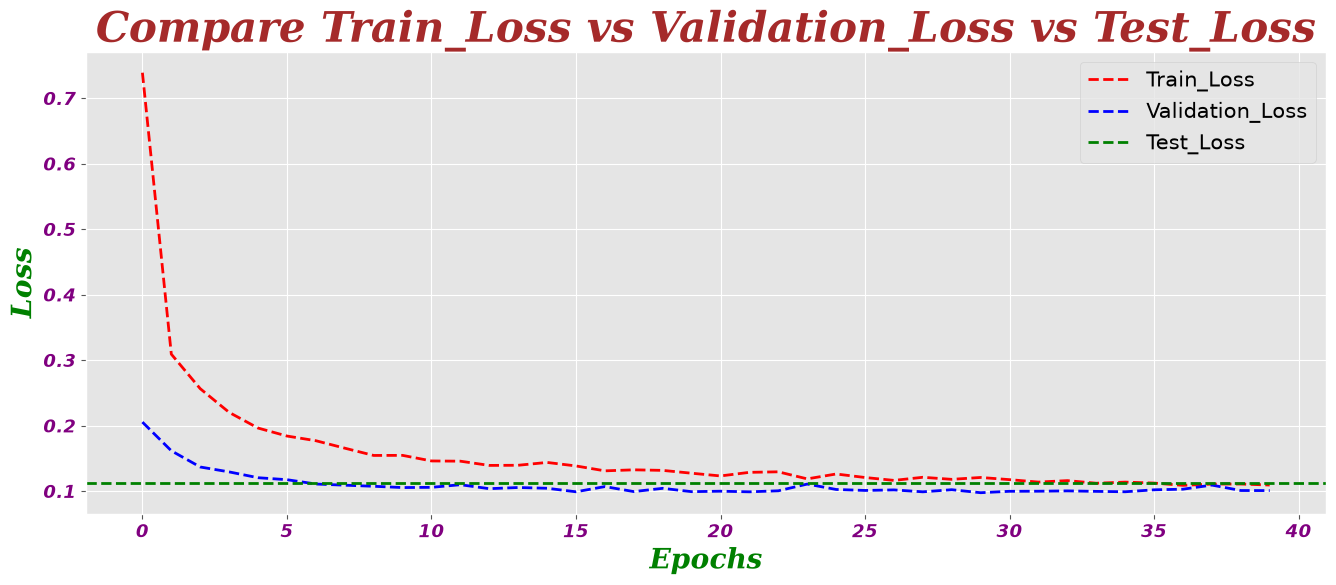

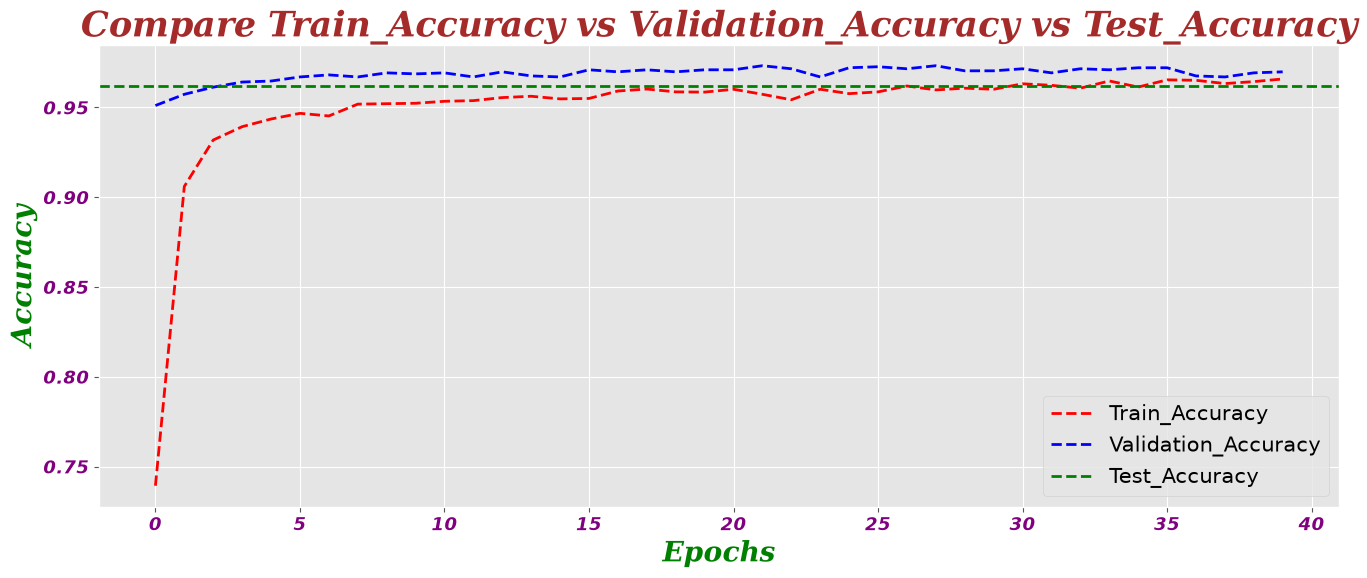

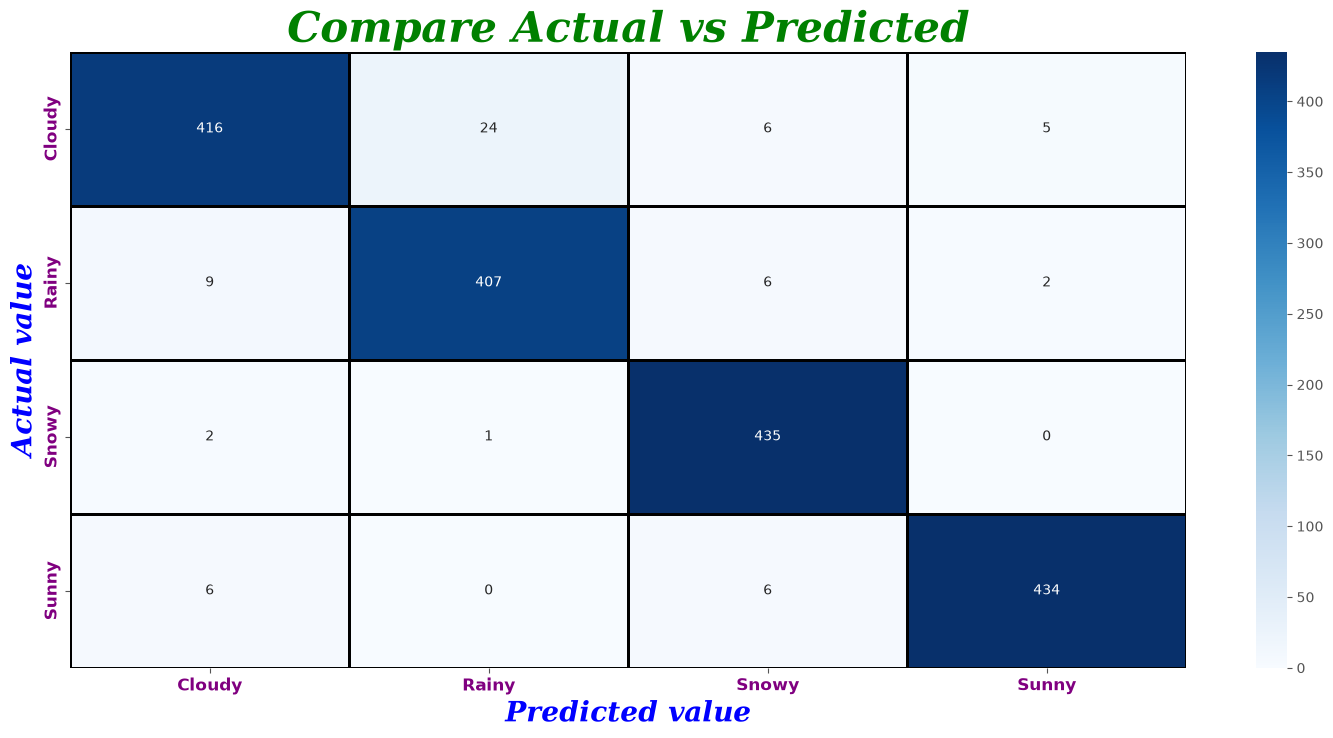

In [6]:
plt.figure(figsize=(16,6))
plt.plot(history.history['loss'],label="Train_Loss",linestyle='--',color='red',linewidth=2)
plt.plot(history.history['val_loss'],label="Validation_Loss",linestyle='--',color='blue',linewidth=2)
plt.axhline(y=test_loss,label="Test_Loss",linestyle='--',color='green',linewidth=2)
plt.xlabel("Epochs",fontsize=20,fontdict={'family':'serif'},fontstyle='italic',fontweight='bold',color='green')
plt.ylabel("Loss",fontsize=20,fontdict={'family':'serif'},fontstyle='italic',fontweight='bold',color='green')
plt.xticks(fontweight='bold',fontstyle='italic',fontsize=13,color='purple')
plt.yticks(fontweight='bold',fontstyle='italic',fontsize=13,color='purple')
plt.title("Compare Train_Loss vs Validation_Loss vs Test_Loss",fontsize=30,fontdict={'family':'serif'},fontstyle='italic',fontweight='bold',color='brown')
plt.legend(loc='upper right',fontsize=15)
plt.show()

plt.figure(figsize=(16,6))
plt.plot(history.history['accuracy'],label="Train_Accuracy",linestyle='--',color='red',linewidth=2)
plt.plot(history.history['val_accuracy'],label="Validation_Accuracy",linestyle='--',color='blue',linewidth=2)
plt.axhline(y=test_accuracy,label="Test_Accuracy",linestyle='--',color='green',linewidth=2)
plt.xlabel("Epochs",fontsize=20,fontdict={'family':'serif'},fontstyle='italic',fontweight='bold',color='green')
plt.ylabel("Accuracy",fontsize=20,fontdict={'family':'serif'},fontstyle='italic',fontweight='bold',color='green')
plt.xticks(fontweight='bold',fontstyle='italic',fontsize=13,color='purple')
plt.yticks(fontweight='bold',fontstyle='italic',fontsize=13,color='purple')
plt.title("Compare Train_Accuracy vs Validation_Accuracy vs Test_Accuracy",fontsize=25,fontdict={'family':'serif'},fontstyle='italic',fontweight='bold',color='brown')
plt.legend(loc='lower right',fontsize=15)
plt.show()

plt.figure(figsize=(18,8))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=le.classes_,yticklabels=le.classes_,linewidths=2,linecolor='black')
plt.title("Compare Actual vs Predicted",fontsize=30,fontdict={'family':'serif'},fontstyle='italic',fontweight='bold',color='green')
plt.xticks(fontsize=12,fontweight='bold',color='purple')
plt.yticks(fontsize=12,fontweight='bold',color='purple')
plt.ylabel("Actual value",fontsize=20,fontdict={'family':'serif'},fontstyle='italic',color='blue',fontweight='bold')
plt.xlabel("Predicted value",fontsize=20,fontdict={'family':'serif'},fontstyle='italic',color='blue',fontweight='bold')
plt.show()

<h1 style = "color:green;font-size:25px;font-style:italic;font-family:sherif;font-weight:bold"> Step 6 : Model Performance Comparison </h1>

In [7]:
table = pd.DataFrame({
    "Model Name":["Decision Tree","Logistic Regression","Random Forest","SVM","KNN","ANN"],
    "Accuracy":[accuracy_score(y_test,dt_Pred),accuracy_score(y_test,lr_Pred),accuracy_score(y_test,rf_Pred),accuracy_score(y_test,svm_Pred),accuracy_score(y_test,knn_Pred),accuracy_score(y_test,y_pred)]
})
print(table)

            Model Name  Accuracy
0        Decision Tree  0.957931
1  Logistic Regression  0.944855
2        Random Forest  0.968732
3                  SVM  0.962479
4                  KNN  0.955088
5                  ANN  0.961910
